## Librerias

In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from tkinter.messagebox import IGNORE
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.vector_ar.var_model import VAR
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout
import keras_tuner as kt
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
import tensorflow as tf
import random
from tensorflow.keras.layers import GRU
from tensorflow.keras.layers import Conv1D, MaxPooling1D, GRU


# PREPROCESAMIENTO

In [26]:
# # EXTRACION DE DATA CRUDA DE EXCEL
df = pd.read_excel("C:\\Users\\Usuario\\Documents\\GitHub\\PROYECTO_MAESTRÍA\\Prediccion-Cizalladura-SKBQ\\docs\\notebooks\\skbo_metar.xlsx")

REVISIONES TEMPERATURA

In [27]:
#head() que no corte el contenido de las columnas
pd.set_option('display.max_colwidth', None)
# filtrar el registro donde fecha reporte es 2006-10-13 07:00:00.000
df_filtrado = df[df['FECHA_REPORTE'] == '2006-10-13 07:00:00.000']
df_filtrado.head()

,ID_ESTACION,FECHA_REPORTE,HORA_REPORTE,TIPO_REPORTE,TEXTO_REPORTE,FECHA_INGRESO,CEDULA,FECHA_HORA_INSERCION,BANDERA
1068,417,2006-10-13 07:00:00.000,2006-10-13 07:00:00.000,METAR,SKBO 130700Z 30002KT 7000 BON017 SCT070 11 /12 A3026 NOSIH,2006-10-13 02:26:19.000,NaN,NaN,E


In [28]:
df_raw = df.copy()

# Eliminar registros inválidos que contienen "NIL"
registros_iniciales = len(df_raw)
invalid_count = df_raw["TEXTO_REPORTE"].str.contains("NIL", na=False).sum()
invalid_percent = (invalid_count / registros_iniciales) * 100

print(f"\n Registros iniciales: {registros_iniciales:,}")
print(f" Registros inválidos (NIL): {invalid_count:,} ({invalid_percent:.2f}%)")

# Eliminar registros inválidos
df_raw = df_raw[~df_raw["TEXTO_REPORTE"].str.contains("NIL", na=False)].copy()

registros_validos = len(df_raw)
print(f" Registros válidos después de limpieza: {registros_validos:,}")
print(f" Registros eliminados: {registros_iniciales - registros_validos:,}")

# Verificar forma después de limpieza
print(f"\n Forma del dataset después de limpieza: {df_raw.shape}")

# Crear columna unificada de fecha y hora
# Las columnas FECHA_REPORTE y HORA_REPORTE contienen información redundante
# Unificamos en una sola columna datetime para facilitar el análisis temporal

print("=" * 60)
print("NORMALIZACIÓN DE FECHAS")
print("=" * 60)

df_raw["FECHA_HORA_REPORTE"] = pd.to_datetime(df_raw["FECHA_REPORTE"].astype(str), errors='coerce')

# Verificar conversión
fechas_invalidas = df_raw["FECHA_HORA_REPORTE"].isna().sum()
if fechas_invalidas > 0:
    print(f"  Advertencia: {fechas_invalidas} fechas no pudieron ser convertidas")

print(f" Columna FECHA_HORA_REPORTE creada")
print(f"   Rango: {df_raw['FECHA_HORA_REPORTE'].min()} a {df_raw['FECHA_HORA_REPORTE'].max()}")

# Extraer componentes temporales para uso posterior
df_raw["Año"] = df_raw["FECHA_HORA_REPORTE"].dt.year
df_raw["Mes"] = df_raw["FECHA_HORA_REPORTE"].dt.month
df_raw["Dia"] = df_raw["FECHA_HORA_REPORTE"].dt.day
df_raw["Hora"] = df_raw["FECHA_HORA_REPORTE"].dt.hour

# Eliminar registro con fecha 1900 si existe (error de datos)
if df_raw[df_raw['Año'] == 1900].shape[0] > 0:
    registros_eliminados_fecha = len(df_raw[df_raw['Año'] == 1900])
    df_raw = df_raw[df_raw['Año'] != 1900].copy()
    print(f" Eliminados {registros_eliminados_fecha} registros con fecha inválida (1900)")

print(f"\n Forma del dataset después de normalización: {df_raw.shape}")

# Verificar valores nulos en el dataframe completo y mostrar resumen
print("=" * 60)
print("VERIFICACIÓN DE VALORES NULOS")
print("=" * 60)
nulos_por_columna = df_raw.isnull().sum()
print(nulos_por_columna[nulos_por_columna > 0])

total_nulos = df_raw.isnull().sum().sum()
#print(f"Total de valores nulos en el dataframe: {total_nulos}")

# Si se quiere enfocar en columnas clave:
columnas_clave = ["FECHA_REPORTE", "TEXTO_REPORTE"]
for col in columnas_clave:
    if col in df_raw.columns:
        nulos = df_raw[col].isnull().sum()
        print(f"{col}: {nulos} nulos")

# 1. Definir el patrón Regex
# \bAUTO\b busca la palabra exacta "AUTO"
# \s? busca un espacio opcional después de la palabra
patron_auto = r'\bAUTO\b\s?'

# 2. Aplicar la limpieza en la columna original
# Usamos regex=True para que interprete el patrón correctamente
df_raw["TEXTO_REPORTE_CLEAN"] = (
    df_raw["TEXTO_REPORTE"]
    .str.replace(patron_auto, "", regex=True, flags=re.IGNORECASE)
    .str.strip() # Elimina espacios al inicio o final si los hubiera
)

# 3. Tokenizar el texto ya limpio
df_raw["tokens"] = df_raw["TEXTO_REPORTE_CLEAN"].str.split()

print(f" Texto tokenizado")
print(f"   Ejemplo de tokens: {df_raw['tokens'].iloc[0][:5]}...")  # Mostrar primeros 5 tokens

df_raw[['TEXTO_REPORTE', 'tokens']].head(3)

# Borrar las filas donde el df_raw["tokens"].str[0] tenga una longitud diferente de 4 osea que el aerodromo fue mal diligenciado
print(f"Forma del DataFrame antes de la limpieza AERODROMO: {df_raw.shape}")

df_raw = df_raw[df_raw['tokens'].str[0].str.len() == 4].copy()

print(f"Forma del DataFrame después de la limpieza AERODROMO: {df_raw.shape}")

# Borrar las filas donde el df_raw["tokens"].str[1] tenga una longitud de 6 y 7 osea que la hora esta completa y tambien que le falto la Z al final
print(f"Forma del DataFrame antes de la limpieza HORA: {df_raw.shape}")

df_raw = df_raw[(df_raw['tokens'].str[1].str.len() == 6) | (df_raw['tokens'].str[1].str.len() == 7)].copy()

print(f"Forma del DataFrame después de la limpieza HORA: {df_raw.shape}")

# Borrar las filas donde el df_raw["tokens"].str[2] tenga una longitud diferente del 6 al 10 osea que la hora esta completa y tambien que le falto la Z al final
print(f"Forma del DataFrame antes de la limpieza VIENTO: {df_raw.shape}")

df_raw = df_raw[df_raw['tokens'].str[2].str.len().isin([6,7,8,9,10])].copy()

print(f"Forma del DataFrame después de la limpieza VIENTO: {df_raw.shape}")

# Paso 2: Extracción de variables meteorológicas usando parsing estructurado
# Los reportes METAR siguen un formato estándar: AERODROMO FECHAZ VIENTO VISIBILIDAD TEMP/ROCIO PRESION NUBOSIDAD FENOMENOS

print("Extrayendo variables meteorológicas...")

# Variables básicas (por posición en el tokenizado)
df_raw["aerodromo"] = df_raw["tokens"].str[0]      # Primer token: código del aeródromo
df_raw["fecha_zulu"] = df_raw["tokens"].str[1]     # Segundo token: fecha Zulu
df_raw["viento"] = df_raw["tokens"].str[2]         # Tercer token: viento
# la temperatura y el rocio no están en el mismo token en todos los reportes, por lo que se hará una extracción más flexible
def encontrar_temperatura_rocio(tokens_series):
    """Busca el token que contiene temperatura/rocío en cualquier posición"""
    
    # Crear una función para aplicar a cada fila
    def buscar_temp_rocio(tokens_list):
            if tokens_list is None:
                return np.nan
                
            if isinstance(tokens_list, str):
                tokens_list = [tokens_list]
            elif not isinstance(tokens_list, (list, tuple, np.ndarray)):
                return np.nan
                
            if len(tokens_list) == 0:
                return np.nan
                
            for token in tokens_list:
                if token is not None:
                    token_str = str(token).strip()
                    
                    # Patrón 1: Buscar formato XX/YY o XX / YY o XX/ YY o XX /YY
                    patron_con_barra = r'(\d{1,3}(?:\.\d+)?)\s*/\s*(\d{1,3}(?:\.\d+)?)'
                    match = re.search(patron_con_barra, token_str)
                    
                    if match:
                        temp_part = match.group(1)
                        rocio_part = match.group(2)
                        return f"{temp_part}/{rocio_part}"
            
            return np.nan
    
    return tokens_series.apply(buscar_temp_rocio)
    


# Aplicar la función mejorada
df_raw["temperatura_rocio"] = encontrar_temperatura_rocio(df_raw["tokens"])
df_raw['temperatura'] = df_raw['temperatura_rocio'].str.split('/').str[0]
df_raw['rocio'] = df_raw['temperatura_rocio'].str.split('/').str[1]


df_preprocesado = df_raw[["FECHA_REPORTE",'Año', 'Mes', 'Dia', 'Hora','viento', 'temperatura', 'rocio']].copy()
print(df_preprocesado.head())

# Exportar el dataset procesado a un archivo CSV
# Este archivo será utilizado en las siguientes etapas del proyecto:
# - Feature engineering
# - Análisis exploratorio avanzado
# - Modelado y predicción

print("=" * 70)
print("EXPORTACIÓN DEL DATASET PROCESADO")
print("=" * 70)
# "/content/drive/MyDrive/MAESTRIA/
ruta_exportacion = 'DATOS_PROCESADOS_temp_roc.csv'

# Verificar que el directorio existe (crearlo si no existe)
#import os
#directorio = os.path.dirname(ruta_exportacion)
#if not os.path.exists(directorio):
#    os.makedirs(directorio, exist_ok=True)
#    print(f" Directorio creado: {directorio}")

# Exportar a CSV
df_preprocesado.to_csv(ruta_exportacion, index=False)

print(f"\n Dataset exportado exitosamente")
print(f"   Ruta: {ruta_exportacion}")
print(f"   Forma: {df_preprocesado.shape[0]:,} registros x {df_preprocesado.shape[1]} columnas")
#print(f"   Tamaño del archivo: {os.path.getsize(ruta_exportacion) / 1024**2:.2f} MB")

# Verificar exportación
df_verificacion = pd.read_csv(ruta_exportacion)
print(f"\n Verificación de exportación:")
print(f"   Registros exportados: {len(df_verificacion):,}")
print(f"   Columnas exportadas: {len(df_verificacion.columns)}")
print(f"   Coincide con original: {len(df_verificacion) == len(df_preprocesado)}")



 Registros iniciales: 171,947
 Registros inválidos (NIL): 2,043 (1.19%)
 Registros válidos después de limpieza: 169,904
 Registros eliminados: 2,043

 Forma del dataset después de limpieza: (169904, 9)
NORMALIZACIÓN DE FECHAS
 Columna FECHA_HORA_REPORTE creada
   Rango: 2006-07-20 00:00:00 a 2026-04-09 18:00:00

 Forma del dataset después de normalización: (169904, 14)
VERIFICACIÓN DE VALORES NULOS
FECHA_INGRESO            18364
CEDULA                  166206
FECHA_HORA_INSERCION     29988
dtype: int64
FECHA_REPORTE: 0 nulos
TEXTO_REPORTE: 0 nulos
 Texto tokenizado
   Ejemplo de tokens: ['SKBO', '200000Z', '03004KT', '9999', 'SCT017']...
Forma del DataFrame antes de la limpieza AERODROMO: (169904, 16)
Forma del DataFrame después de la limpieza AERODROMO: (169875, 16)
Forma del DataFrame antes de la limpieza HORA: (169875, 16)
Forma del DataFrame después de la limpieza HORA: (169866, 16)
Forma del DataFrame antes de la limpieza VIENTO: (169866, 16)
Forma del DataFrame después de la lim

In [29]:
df_preprocesado[df_preprocesado['FECHA_REPORTE'] == '2021-12-13 01:00:00.000']

,FECHA_REPORTE,Año,Mes,Dia,Hora,viento,temperatura,rocio
129827,2021-12-13 01:00:00.000,2021,12,13,1,2905KT,12,10


# VERIFICACION DATOS FALTANTES

In [57]:
# EXTRACION DE DATA PREPROCESADA
df_datos_preprocesados = pd.read_csv('C:\\Users\\Usuario\\Documents\\GitHub\\PROYECTO_MAESTRÍA\\Prediccion-Cizalladura-SKBQ\\docs\\notebooks\\DATOS_PROCESADOS_temp_roc.csv')

In [58]:
df_pre_copy = df_datos_preprocesados.copy()

In [59]:
df_pre_copy.head()

,FECHA_REPORTE,Año,Mes,Dia,Hora,viento,temperatura,rocio
0,2006-07-20 00:00:00.000,2006,7,20,0,03004KT,13.0,8.0
1,2006-07-20 01:00:00.000,2006,7,20,1,29004KT,11.0,10.0
2,2006-07-20 05:00:00.000,2006,7,20,5,VRB02KT,9.0,9.0
3,2006-07-20 06:00:00.000,2006,7,20,6,VRB02KT,8.0,8.0
4,2006-07-20 07:00:00.000,2006,7,20,7,VRB02KT,9.0,8.0


valores nulos en temperatura y rocio

In [60]:
#contar el numero de registros donde las columnas de temperatura y punto de rocío son nulas vs cantidad de registros totales
total_registros = len(df_pre_copy)
nulos_temperatura = df_pre_copy['temperatura'].isnull().sum()
nulos_rocio = df_pre_copy['rocio'].isnull().sum()
print(f"Total de registros: {total_registros}")
print(f"Registros con temperatura nula: {nulos_temperatura} ({(nulos_temperatura / total_registros) * 100:.2f}%)")
print(f"Registros con punto de rocío nulo: {nulos_rocio} ({(nulos_rocio / total_registros) * 100:.2f}%)")
#mostrar registros con temperatura nula pero con punto de rocío no nulo
diferencias =df_pre_copy[(df_pre_copy['temperatura'].isnull()) & (df_pre_copy['rocio'].notnull())]
print(f"Registros con temperatura nula pero punto de rocío no nulo: {len(diferencias)}")
df_pre_copy[df_pre_copy['temperatura'].isnull()].head()

Total de registros: 169764
Registros con temperatura nula: 267 (0.16%)
Registros con punto de rocío nulo: 267 (0.16%)
Registros con temperatura nula pero punto de rocío no nulo: 0


,FECHA_REPORTE,Año,Mes,Dia,Hora,viento,temperatura,rocio
282,2006-09-05 10:00:00.000,2006,9,5,10,31003KT,NaN,NaN
401,2006-09-11 09:00:00.000,2006,9,11,9,VRB02KT,NaN,NaN
1066,2006-10-13 07:00:00.000,2006,10,13,7,30002KT,NaN,NaN
1420,2006-12-28 13:00:00.000,2006,12,28,13,02005KT,NaN,NaN
1874,2007-03-23 00:00:00.000,2007,3,23,0,VRB02KT,NaN,NaN


In [61]:
#Validación de reportes originales para saber si está informando correctamente estos valores faltantes
df_filtrado = df[df['FECHA_REPORTE'].isin(['2006-09-05 10:00:00.000','2006-09-11 09:00:00.000','2006-10-13 07:00:00.000','2006-12-28 13:00:00.000'])]
df_filtrado.head()

,ID_ESTACION,FECHA_REPORTE,HORA_REPORTE,TIPO_REPORTE,TEXTO_REPORTE,FECHA_INGRESO,CEDULA,FECHA_HORA_INSERCION,BANDERA
284,417,2006-09-05 10:00:00.000,2006-09-05 10:00:00.000,METAR,SKBO 051000Z 31003KT 9999 MIFG SCT017 SCT200 0909 A3034 NOSIG,2006-09-05 05:38:20.000,NaN,NaN,L
403,417,2006-09-11 09:00:00.000,2006-09-11 09:00:00.000,METAR,SKBO 110900Z VRB02KT 9999 SCT018 08/ 08 A3028,2006-09-11 04:40:24.000,NaN,NaN,L
1068,417,2006-10-13 07:00:00.000,2006-10-13 07:00:00.000,METAR,SKBO 130700Z 30002KT 7000 BON017 SCT070 11 /12 A3026 NOSIH,2006-10-13 02:26:19.000,NaN,NaN,E
1422,417,2006-12-28 13:00:00.000,2006-12-28 13:00:00.000,METAR,SKBO 281300Z 02005KT 9999 FEW020 1310 A3039 NOSIG,2006-12-28 08:47:02.000,NaN,NaN,E


In [62]:
# Convertir FECHA_HORA_REPORTE a datetime y establecer como índice
df_pre_copy['FECHA_REPORTE'] = pd.to_datetime(df_pre_copy['FECHA_REPORTE'])
df_pre_copy.set_index('FECHA_REPORTE', inplace=True)

# Eliminación de variables no necesarias, solo me quedo con la columna de viento
df_pre_copy.drop(columns=['Año', 'Mes', 'Dia', 'Hora'], inplace=True)

# Eliminar valores nulos en la columna 'viento' antes de aplicar el parseo
df_pre_copy = df_pre_copy[df_pre_copy['viento'].notna()]

# Modificar el valor KKT, T, K  por KT en la columna de viento
df_pre_copy['viento'] = df_pre_copy['viento'].str.replace(r'[A-Za-z]{3}$', 'KT', regex=True)

def parse_viento_flexible(cadena):
    if pd.isna(cadena) or not isinstance(cadena, str):
        return pd.Series([None, None, None])

    patron = r'^(\d{3}|VRB)(\d{2,3})(G\d{2,3})?KT$'
    match = re.match(patron, cadena)

    if match:
        dir_raw = match.group(1)
        vel_raw = match.group(2)
        gus_raw = match.group(3)

        direccion = float(dir_raw) if dir_raw != 'VRB' else None
        velocidad = float(vel_raw)

        # CORRECCIÓN: Si no hay ráfaga (gus_raw es None), ponemos 0
        rafaga = float(gus_raw[1:]) if gus_raw else 0.0

        return pd.Series([direccion, velocidad, rafaga])

    return pd.Series([None, None, None])

# Aplicación Regex para parsear la columna de viento con formato flexible
df_pre_copy[['direccion', 'intensidad_kt', 'rafaga_kt']] = df_pre_copy['viento'].apply(parse_viento_flexible)

# Toma el último grado válido (ej. 030) y lo pone donde estaba el NaN de 'VRB'
df_pre_copy['direccion'] = df_pre_copy['direccion'].ffill()

# Elimino errores de digitación, por lo cual me quedo cuando la longitud de viento es mayor a 7
df_pre_copy = df_pre_copy[df_pre_copy['viento'].str.len() > 6]

# Elimino aquellos que no se identifica intensidad del viento
df_pre_copy = df_pre_copy[df_pre_copy["intensidad_kt"].notnull()]

# Verificar cuantos no tienen la estructura
df_pre_copy["viento"].str.len().value_counts()

# Eliminar valores donde la dirección es muy desfazada
df_pre_copy = df_pre_copy[df_pre_copy["direccion"] <= 360]


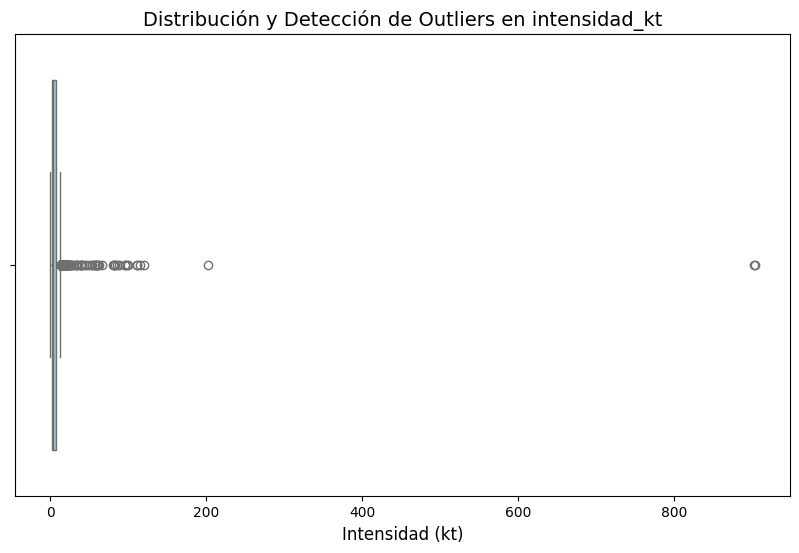

In [63]:
# Verificación outliers

# Configurar el tamaño de la figura (opcional, pero recomendado)
plt.figure(figsize=(10, 6))

# Crear el boxplot de la columna "intensidad_kt"
# Usamos orient='h' para que sea horizontal, suele facilitar la lectura de la dispersión
sns.boxplot(x=df_pre_copy["intensidad_kt"], color='skyblue')

# Añadir título y etiquetas
plt.title('Distribución y Detección de Outliers en intensidad_kt', fontsize=14)
plt.xlabel('Intensidad (kt)', fontsize=12)

# Mostrar el gráfico
plt.show()

# Noticia de vientos de bogota https://portal.gestiondelriesgo.gov.co/paginas/old_noticias/225.aspx
# https://portal.gestiondelriesgo.gov.co/paginas/old_noticias/225.aspx

# umbral para la sabana de Bogotá
umbral_maximo = 40

# Todo valor mayor al umbral se vuelve nulo ANTES de cualquier cálculo
df_pre_copy.loc[df_pre_copy['intensidad_kt'] > umbral_maximo, 'intensidad_kt'] = np.nan

### Datos faltantes

In [ ]:
# 1. Crear el horario maestro (ejemplo: cada 1 hora)
rango_teorico = pd.date_range(start=df_pre_copy.index.min().floor('h'),
                              end=df_pre_copy.index.max().ceil('h'),
                              freq='1h')

# 2. Identificar qué horas del maestro no están en tus datos
horas_faltantes = rango_teorico.difference(df_pre_copy.index)
print(f"Total de reportes faltantes: {len(horas_faltantes)}")

# Identificar reportes que no ocurren exactamente en la hora (minuto != 0)
reportes_especiales = df_pre_copy[df_pre_copy.index.minute != 0]
print(f"Reportes extra encontrados: {len(reportes_especiales)}")

Total de reportes faltantes: 13337
Reportes extra encontrados: 9782


C:\Users\Usuario\AppData\Local\Temp\ipykernel_31556\1832988519.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  rango_teorico = pd.date_range(start=df_pre_copy.index.min().floor('H'),
C:\Users\Usuario\AppData\Local\Temp\ipykernel_31556\1832988519.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  end=df_pre_copy.index.max().ceil('H'),


#### Descomposicion de dirección e intensidad del viento

In [65]:
# =========================================================
# FASE 1: PREPARACIÓN DEL ÍNDICE Y CÁLCULO DE COMPONENTES
# =========================================================

# Asegurarnos de que el índice de dataset original es formato datetime
df_pre_copy.index = pd.to_datetime(df_pre_copy.index)

# PASO CRÍTICO: Redondear los reportes a la hora en punto más cercana.
# Esto sincroniza reportes emitidos al minuto 50-59 con la hora exacta.
df_pre_copy.index = df_pre_copy.index.round('H')

# Al redondear, un reporte regular y un reporte especial (SPECI) podrían caer
# en la misma hora. Conservamos el último (el más actualizado).
df_pre_copy = df_pre_copy[~df_pre_copy.index.duplicated(keep='last')]

# Calcular u y v desde cero:
df_pre_copy['dir_sin'] = np.sin(np.radians(df_pre_copy['direccion'])) 
df_pre_copy['dir_cos'] = np.cos(np.radians(df_pre_copy['direccion']))

# Transformación logaritmica para intensidad
df_pre_copy['intensidad_log'] = np.log1p(df_pre_copy['intensidad_kt'])  # log(1 + x) para manejar ceros

C:\Users\Usuario\AppData\Local\Temp\ipykernel_31556\4520324.py:10: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_pre_copy.index = df_pre_copy.index.round('H')


In [116]:
#calculo de u y v
df_pre_copy['u'] = -df_pre_copy['intensidad_kt'] * np.sin(np.radians(df_pre_copy['direccion']))
df_pre_copy['v'] = -df_pre_copy['intensidad_kt'] * np.cos(np.radians(df_pre_copy['direccion']))

In [117]:
df_pre_copy.head()

,viento,temperatura,rocio,direccion,intensidad_kt,rafaga_kt,dir_sin,dir_cos,intensidad_log,u,v
FECHA_REPORTE,,,,,,,,,,,
2006-07-20 00:00:00,03004KT,13.0,8.0,30.0,4.0,0.0,0.500000,0.866025,1.609438,-2.000000,-3.464102
2006-07-20 01:00:00,29004KT,11.0,10.0,290.0,4.0,0.0,-0.939693,0.342020,1.609438,3.758770,-1.368081
2006-07-20 05:00:00,VRB02KT,9.0,9.0,290.0,2.0,0.0,-0.939693,0.342020,1.098612,1.879385,-0.684040
2006-07-20 06:00:00,VRB02KT,8.0,8.0,290.0,2.0,0.0,-0.939693,0.342020,1.098612,1.879385,-0.684040
2006-07-20 07:00:00,VRB02KT,9.0,8.0,290.0,2.0,0.0,-0.939693,0.342020,1.098612,1.879385,-0.684040


Los mejores datos a tomar para que luego de la imputacion ,no se presente mucho sesgo es desde el 2013 (inclusive).

In [67]:
# 1. Transformación Vectorial (u, v) - HACER ANTES DEL RESAMPLE


# 2. Definir reglas de agregación para tus columnas
reglas = {
    'dir_sin': 'mean',          # Promedio de la componente zonal
    'dir_cos': 'mean',          # Promedio de la componente meridional
    'intensidad_kt': 'mean',    # Promedio de intensidad (antes del log)
    'intensidad_log': 'mean',
    'rafaga_kt': 'max',    # Capturamos la ráfaga más fuerte de la hora
    'temperatura': 'mean', # Promedio de temperatura
    'rocio': 'mean'       # Promedio de punto de rocío
}

# 3. Forzar la frecuencia horaria (Resample)
df_modelo = df_pre_copy.resample('1H').agg(reglas)

# 4. Mantener la continuidad para el modelo (Interpolación)
# El LSTM requiere que no existan huecos en la secuencia
df_modelo['dir_sin'] = df_modelo['dir_sin'].interpolate(method='linear')
df_modelo['dir_cos'] = df_modelo['dir_cos'].interpolate(method='linear')
df_modelo['intensidad_kt'] = df_modelo['intensidad_kt'].interpolate(method='linear')
df_modelo['intensidad_log'] = df_modelo['intensidad_log'].interpolate(method='linear')
df_modelo['rafaga_kt'] = df_modelo['rafaga_kt'].fillna(0) # Si no hay reporte, rafaga es 0
# Conservar las columnas 'temperatura' y 'rocio' en df_modelo
df_modelo['temperatura'] = df_modelo['temperatura'].interpolate(method='linear')
df_modelo['rocio'] = df_modelo['rocio'].interpolate(method='linear')

C:\Users\Usuario\AppData\Local\Temp\ipykernel_31556\3101404825.py:16: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_modelo = df_pre_copy.resample('1H').agg(reglas)


In [68]:
# Muestra la sumatoria de valores NaN en cada columna
print("Cantidad de valores faltantes por columna:")
print(df_modelo.isnull().sum())

# Verifica si la frecuencia horaria es estrictamente regular
print("\n¿Es el índice estrictamente regular (1H)?:", pd.infer_freq(df_modelo.index) == 'H')

Cantidad de valores faltantes por columna:
dir_sin           0
dir_cos           0
intensidad_kt     0
intensidad_log    0
rafaga_kt         0
temperatura       0
rocio             0
dtype: int64

¿Es el índice estrictamente regular (1H)?: False


In [69]:
# 1. Asignar la frecuencia horaria de forma estricta
df_modelo = df_modelo.asfreq('H')

# 2. Verificar que la etiqueta 'freq' se haya asignado correctamente
print("Frecuencia oficial del índice:", df_modelo.index.freq)

Frecuencia oficial del índice: <Hour>


C:\Users\Usuario\AppData\Local\Temp\ipykernel_31556\567216096.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_modelo = df_modelo.asfreq('H')


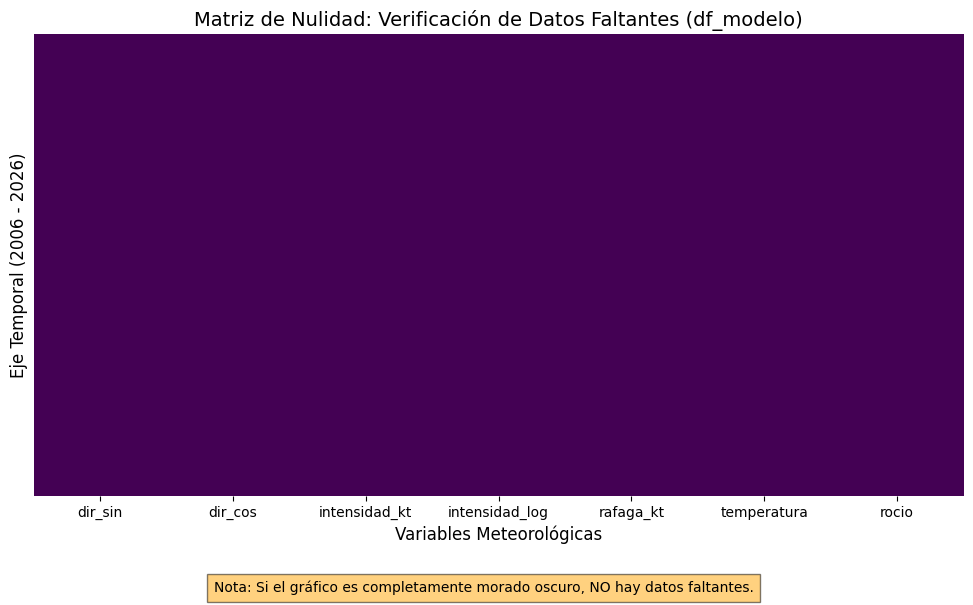

In [70]:
# Configurar el tamaño del gráfico
plt.figure(figsize=(12, 6))

# Crear un heatmap directamente sobre los valores booleanos de df.isnull()
# cbar=False quita la barra lateral, yticklabels=False oculta las miles de fechas del eje Y
sns.heatmap(df_modelo.isnull(), cbar=False, cmap='viridis', yticklabels=False)

plt.title('Matriz de Nulidad: Verificación de Datos Faltantes (df_modelo)', fontsize=14)
plt.xlabel('Variables Meteorológicas', fontsize=12)
plt.ylabel('Eje Temporal (2006 - 2026)', fontsize=12)

# Añadir un texto explicativo dentro del gráfico
plt.figtext(0.5, -0.05, "Nota: Si el gráfico es completamente morado oscuro, NO hay datos faltantes.",
            ha="center", fontsize=10, bbox={"facecolor":"orange", "alpha":0.5, "pad":5})

plt.show()

In [71]:
# Filtrar desde 2013
df_lstm = df_modelo.loc['2013-01-01':, ['dir_sin', 'dir_cos', 'intensidad_kt', 'intensidad_log', 'temperatura', 'rocio']].copy()

In [75]:
# "/content/drive/MyDrive/MAESTRIA/
ruta_exportacion = 'DATOS_ENTRENAMIENTO_con_temp_roc_dirsen_sircos_intensidad_log.csv'

# Verificar que el directorio existe (crearlo si no existe)
#import os
#directorio = os.path.dirname(ruta_exportacion)
#if not os.path.exists(directorio):
#    os.makedirs(directorio, exist_ok=True)
#    print(f" Directorio creado: {directorio}")

# Exportar a CSV
df_lstm.to_csv(ruta_exportacion, index=True)

In [91]:
# Leer archivo para futuras etapas de modelado y predicción
df_verificacion = pd.read_csv(r"C:\Users\Usuario\Documents\GitHub\PROYECTO_MAESTRÍA\Prediccion-Cizalladura-SKBQ\docs\notebooks\DATOS_ENTRENAMIENTO_con_temp_roc_dirsen_sircos_intensidad_log.csv",
                             parse_dates=['FECHA_REPORTE'], index_col='FECHA_REPORTE')
df_verificacion.head()

,dir_sin,dir_cos,intensidad_kt,intensidad_log,temperatura,rocio
FECHA_REPORTE,,,,,,
2013-01-01 00:00:00,0.173648,0.984808,3.0,1.386294,14.0,6.0
2013-01-01 01:00:00,0.500000,0.866025,5.0,1.791759,13.0,7.0
2013-01-01 02:00:00,0.939693,0.342020,3.0,1.386294,13.0,7.0
2013-01-01 03:00:00,0.500000,0.866025,3.0,1.386294,10.0,7.0
2013-01-01 04:00:00,0.500000,0.866025,4.0,1.609438,9.0,7.0


In [176]:
df_lstm = df_verificacion.copy()
df_lstm.head()

,dir_sin,dir_cos,intensidad_kt,intensidad_log,temperatura,rocio
FECHA_REPORTE,,,,,,
2013-01-01 00:00:00,0.173648,0.984808,3.0,1.386294,14.0,6.0
2013-01-01 01:00:00,0.500000,0.866025,5.0,1.791759,13.0,7.0
2013-01-01 02:00:00,0.939693,0.342020,3.0,1.386294,13.0,7.0
2013-01-01 03:00:00,0.500000,0.866025,3.0,1.386294,10.0,7.0
2013-01-01 04:00:00,0.500000,0.866025,4.0,1.609438,9.0,7.0


In [157]:
# Ver si 2025 y 2026 son atípicos respecto al histórico
print("Intensidad promedio por año (intensidad_log):")
print(df_lstm.groupby(df_lstm.index.year)['intensidad_log'].mean().round(4))

print("\nDirección promedio por año (dir_sin y dir_cos):")
print(df_lstm.groupby(df_lstm.index.year)[['dir_sin', 'dir_cos']].mean().round(4))

# Adicionalmente, reconstruir la dirección promedio en grados para interpretarla mejor
dir_media_anual = df_lstm.groupby(df_lstm.index.year)[['dir_sin', 'dir_cos']].mean()
dir_media_anual['direccion_grados'] = (
    np.degrees(np.arctan2(dir_media_anual['dir_sin'], dir_media_anual['dir_cos'])) % 360
).round(1)

# Reconstruir intensidad promedio en kt
intensidad_media_anual = np.expm1(df_lstm.groupby(df_lstm.index.year)['intensidad_log'].mean())

print("\n=== RESUMEN ANUAL ===")
print(f"{'Año':<6} {'Dir promedio (°)':<20} {'Intensidad promedio (kt)'}")
for year in dir_media_anual.index:
    print(f"{year:<6} {dir_media_anual.loc[year, 'direccion_grados']:<20} {intensidad_media_anual[year]:.2f}")

Intensidad promedio por año (intensidad_log):
FECHA_REPORTE
2013    1.7343
2014    1.7144
2015    1.8076
2016    1.7289
2017    1.7161
2018    1.7275
2019    1.7468
2020    1.6968
2021    1.6808
2022    1.6233
2023    1.7097
2024    1.7331
2025    1.6566
2026    1.5980
Name: intensidad_log, dtype: float64

Dirección promedio por año (dir_sin y dir_cos):
               dir_sin  dir_cos
FECHA_REPORTE                  
2013            0.1796   0.2747
2014            0.2254   0.2638
2015            0.3397   0.1461
2016            0.1187   0.2451
2017            0.0621   0.2548
2018            0.1478   0.2397
2019            0.1932   0.2258
2020            0.0761   0.2543
2021            0.0559   0.2788
2022           -0.0325   0.3317
2023            0.1522   0.2319
2024            0.1295   0.2325
2025            0.1463   0.2645
2026           -0.0208   0.3893

=== RESUMEN ANUAL ===
Año    Dir promedio (°)     Intensidad promedio (kt)
2013   33.2                 4.67
2014   40.5            

# PRUEBA DE MODELOS

## LSTM

In [177]:
# Ajustar nombres reales de columnas en df_lstm
features_modelo = ['dir_sin', 'dir_cos', 'intensidad_log', 'temperatura', 'rocio']
X = df_lstm[features_modelo].values

# Lo que el modelo va a predecir
targets = ['dir_sin', 'dir_cos', 'intensidad_log']
y = df_lstm[targets].values

# ========== 2. PARTICIÓN CRONOLÓGICA CON DATOS NORMALIZADOS ==========
print("Realizando partición cronológica...")

# Train: 2013 hasta finales de 2024
train_df = df_lstm.loc[:'2024-12-31']

# Val: Todo el año 2025 (para el Keras Tuner / Early Stopping)
val_df = df_lstm.loc['2025-01-01':'2025-12-31']

# Test: Datos del 2026 (Para evaluación final fuera de muestra)
test_df = df_lstm.loc['2026-01-01':]

print(f"Train: {train_df.shape[0]}")
print(f"Val: {val_df.shape[0]} muestras")
print(f"Test: {test_df.shape[0]} muestras")

# ========== 2. ESCALAR SOLO CON TRAIN (fit), aplicar a todos (transform) ==========
print("\nNormalizando variables...")
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# fit SOLO con train, transform a los tres conjuntos
Xtrain_data = scaler_X.fit_transform(train_df[features_modelo].to_numpy())
Xval_data   = scaler_X.transform(val_df[features_modelo].to_numpy())
Xtest_data  = scaler_X.transform(test_df[features_modelo].to_numpy())

y_train = scaler_y.fit_transform(train_df[targets].to_numpy())
y_val   = scaler_y.transform(val_df[targets].to_numpy())
y_test  = scaler_y.transform(test_df[targets].to_numpy())

print(f"\nXtrain: {Xtrain_data.shape} | y_train: {y_train.shape}")
print(f"Xval:   {Xval_data.shape}   | y_val:   {y_val.shape}")
print(f"Xtest:  {Xtest_data.shape}  | y_test:  {y_test.shape}")

# ========== 3. VERIFICACIÓN DE SANIDAD ==========
# La intensidad reconstruida no debe tener negativos
y_train_orig = scaler_y.inverse_transform(y_train)
intensidades = np.expm1(y_train_orig[:, 2])
print(f"\nIntensidad mín en train: {intensidades.min():.2f} kt")
print(f"Intensidad máx en train: {intensidades.max():.2f} kt")
# Si mín >= 0, todo está bien

Realizando partición cronológica...
Train: 105192
Val: 8760 muestras
Test: 2371 muestras

Normalizando variables...

Xtrain: (105192, 5) | y_train: (105192, 3)
Xval:   (8760, 5)   | y_val:   (8760, 3)
Xtest:  (2371, 5)  | y_test:  (2371, 3)

Intensidad mín en train: 0.00 kt
Intensidad máx en train: 40.00 kt


In [178]:
# ========== DIAGNÓSTICO ==========

# 1. Ver cómo está intensidad_log en el CSV original
print("Estadísticas de intensidad_log en el CSV:")
print(df_lstm['intensidad_log'].describe())
print(f"\nValores negativos: {(df_lstm['intensidad_log'] < 0).sum()}")
print(f"Valores == 0: {(df_lstm['intensidad_log'] == 0).sum()}")

# 2. Ver cómo está intensidad_kt antes del log
print("\nEstadísticas de intensidad_kt (antes del log):")
print(df_lstm['intensidad_kt'].describe())  # o como se llame en tu df original
print(f"Valores negativos en intensidad_kt: {(df_lstm['intensidad_kt'] < 0).sum()}")

# 3. Ver los registros problemáticos
print("\nRegistros con intensidad_log < 0:")
print(df_lstm[df_lstm['intensidad_log'] < 0][['intensidad_log']].head(10))

Estadísticas de intensidad_log en el CSV:
count    116323.000000
mean          1.711181
std           0.525776
min           0.000000
25%           1.386294
50%           1.609438
75%           2.079442
max           3.713572
Name: intensidad_log, dtype: float64

Valores negativos: 0
Valores == 0: 2003

Estadísticas de intensidad_kt (antes del log):
count    116323.000000
mean          5.322340
std           3.300185
min           0.000000
25%           3.000000
50%           4.000000
75%           7.000000
max          40.000000
Name: intensidad_kt, dtype: float64
Valores negativos en intensidad_kt: 0

Registros con intensidad_log < 0:
Empty DataFrame
Columns: [intensidad_log]
Index: []


Generación secuencias para LSTM

In [179]:
# Parámetros metodológicos
n_back = 48  # Nuestra ventana óptima de rezagos (reemplaza al 15 de tu notebook)
batch_size_train = 256 # Un lote más grande acelera el entrenamiento en TF
batch_size_test = 1    # Como en tu notebook, batch_size=1 en test facilita la inferencia

# 1. Generador de Entrenamiento
train_generator = TimeseriesGenerator( Xtrain_data, y_train,
                                      length=n_back, batch_size=batch_size_train)

# 2. Generador de Validación
val_generator = TimeseriesGenerator(Xval_data, y_val, 
                                    length=n_back, batch_size=batch_size_train)

# 3. Generador de Prueba
test_generator = TimeseriesGenerator(Xtest_data, y_test, 
                                     length=n_back, batch_size=batch_size_test)

# --- Verificación de la estructura ---
x_batch, y_batch = train_generator[0]
print(f"\nGenerador configurado exitosamente.")
print(f"Estructura del lote X: {x_batch.shape} -> (Batch_size, n_back, features)")
print(f"Estructura del lote y: {y_batch.shape} -> (Batch_size, features)")


Generador configurado exitosamente.
Estructura del lote X: (256, 48, 5) -> (Batch_size, n_back, features)
Estructura del lote y: (256, 3) -> (Batch_size, features)


Entrenamiento modelo LSTM

Estructura de la Red Neuronal:


c:\Users\Usuario\Documents\MAESTRÍA\Semestre 2\Deep learning\condapython3_9\.conda\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                  │ (None, 200)            │       164,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 3)              │           603 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 165,403 (646.11 KB)

 Trainable params: 165,403 (646.11 KB)

 Non-trainable params: 0 (0.00 B)


Iniciando entrenamiento...
Epoch 1/25


c:\Users\Usuario\Documents\MAESTRÍA\Semestre 2\Deep learning\condapython3_9\.conda\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


377/377 ━━━━━━━━━━━━━━━━━━━━ 96s 245ms/step - loss: 129054707548160.0000 - val_loss: 5.6225
Epoch 2/25
377/377 ━━━━━━━━━━━━━━━━━━━━ 58s 155ms/step - loss: 2605301248.0000 - val_loss: 5.4333
Epoch 3/25
377/377 ━━━━━━━━━━━━━━━━━━━━ 55s 146ms/step - loss: 433475.5625 - val_loss: 5.3333
Epoch 4/25
377/377 ━━━━━━━━━━━━━━━━━━━━ 56s 148ms/step - loss: 45462.8555 - val_loss: 5.2294
Epoch 5/25
377/377 ━━━━━━━━━━━━━━━━━━━━ 56s 148ms/step - loss: 165826.6719 - val_loss: 5.1526
Epoch 6/25
377/377 ━━━━━━━━━━━━━━━━━━━━ 54s 143ms/step - loss: 178473.0469 - val_loss: 5.0971
Epoch 7/25
377/377 ━━━━━━━━━━━━━━━━━━━━ 54s 144ms/step - loss: 2608.2932 - val_loss: 5.0395
Epoch 8/25
377/377 ━━━━━━━━━━━━━━━━━━━━ 54s 143ms/step - loss: 22180.0586 - val_loss: 4.9910
Epoch 9/25
377/377 ━━━━━━━━━━━━━━━━━━━━ 55s 146ms/step - loss: 11152.8203 - val_loss: 4.9503
Epoch 10/25
377/377 ━━━━━━━━━━━━━━━━━━━━ 55s 145ms/step - loss: 18907.4004 - val_loss: 4.9167
Epoch 11/25
377/377 ━━━━━━━━━━━━━━━━━━━━ 54s 144ms/step - loss:

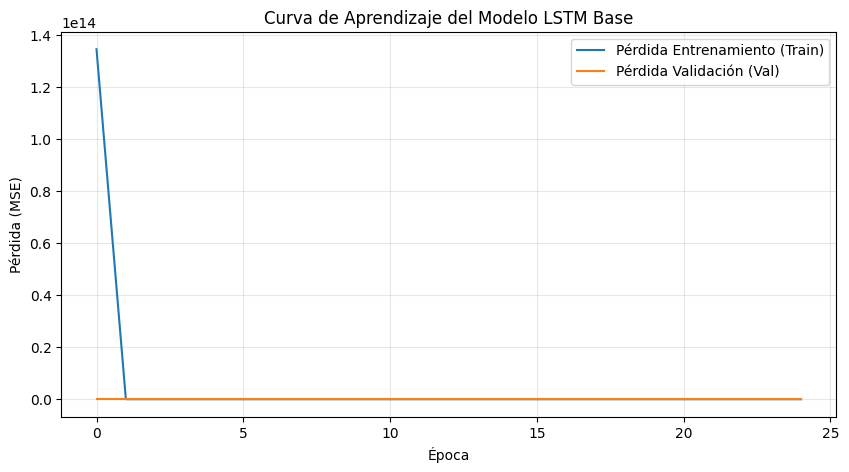

In [ ]:
# Número de variables entradas (dir_sin, dir_cos,intensidad_log, temperatura, rocio)
n_features = 5
n_outputs = 3  # Solo queremos predecir dir_sin, dir_cos,intensidad_log

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# 1. Diseño de la Arquitectura del Modelo
model = Sequential()
# Modelo Enhanced Stacked LSTM con múltiples capas y dropout
model.add(LSTM(200, return_sequences=True, input_shape=(n_back, n_features)))
model.add(Dropout(0.2))
model.add(LSTM(100, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(50, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(n_outputs, activation='linear'))

def perdida_circular(y_true, y_pred):
    """
    y_true y y_pred tienen forma (batch, 3) -> [dir_sin, dir_cos, intensidad_log]
    Penaliza el error angular correctamente + error de intensidad
    """
    # Error en sin y cos (captura circularidad automáticamente)
    error_sin = tf.square(y_true[:, 0] - y_pred[:, 0])
    error_cos = tf.square(y_true[:, 1] - y_pred[:, 1])
    error_dir = error_sin + error_cos  # equivalente al error angular en el círculo unitario

    # Error en intensidad
    error_int = tf.square(y_true[:, 2] - y_pred[:, 2])

    # Peso mayor a dirección si quieres priorizar ese error
    return tf.reduce_mean(4.0 * error_dir + error_int)

def perdida_circular_huber(y_true, y_pred):
    # Dirección: pérdida circular con peso 4.0
    error_sin = tf.square(y_true[:, 0] - y_pred[:, 0])
    error_cos = tf.square(y_true[:, 1] - y_pred[:, 1])
    error_dir = error_sin + error_cos

    # Intensidad: Huber (más robusto a outliers de viento)
    delta         = 1.0
    error_int_abs = tf.abs(y_true[:, 2] - y_pred[:, 2])
    error_int     = tf.where(
        error_int_abs <= delta,
        0.5 * tf.square(error_int_abs),
        delta * (error_int_abs - 0.5 * delta)
    )

    return tf.reduce_mean(4.0 * error_dir + error_int)




# 2. Compilación
model.compile(optimizer='adam', loss=perdida_circular)
print("Estructura de la Red Neuronal:")
model.summary()
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,       # reducir de 5 a 3
    restore_best_weights=True,
    verbose=1
)
# 3. Entrenamiento (con validación en 2025 para monitorear)
num_epochs = 25

print("\nIniciando entrenamiento...")
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=num_epochs,
    verbose=1,  # verbose=1 para que veas la barra de progreso
    callbacks=[early_stop]
)

# 4. Visualización de la Curva de Aprendizaje
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Pérdida Entrenamiento (Train)')
plt.plot(history.history['val_loss'], label='Pérdida Validación (Val)')
plt.title('Curva de Aprendizaje del Modelo LSTM Base')
plt.xlabel('Época')
plt.ylabel('Pérdida (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Prueba de concepto a 6h

In [171]:
def predict_autoregressive(modelo, initial_window, exog_future, horizon):
    """
    Realiza el pronóstico iterativo hacia el futuro.
    - initial_window: Array con forma (1, n_back, n_features). Ej: (1, 48, 5)
    - exog_future: Variables exógenas futuras (temperatura y rocio). Forma (horizon, 2)
    - horizon: Cantidad de pasos a predecir (6 horas)
    """
    current_window = np.copy(initial_window)
    predictions = []
    
    for i in range(horizon):
        
        # 1. Predecir dir_sin, dir_cos, intensidad_log
        next_uv = modelo.predict(current_window, verbose=0)  # (1, 3)
        
        predictions.append(next_uv[0])
        
        # 2. Tomar temperatura y rocío reales futuros
        temp_rocio = exog_future[i]  # (2,)
        
        # 3. Construir el nuevo timestep completo (5 variables)
        next_step_full = np.concatenate([next_uv[0], temp_rocio])  # (5,)
        
        # 4. Expandir a 3D
        next_step_full_3d = next_step_full.reshape(1, 1, 5)
        
        # 5. Actualizar ventana
        current_window = np.concatenate(
            [current_window[:, 1:, :], next_step_full_3d],
            axis=1
        )
    
    return np.array(predictions)  # (horizon, 3)

# --- Prueba del Motor de Inferencia ---
# Vamos a tomar las ÚLTIMAS 48 horas de tu set de validación (2025)
# para predecir las PRIMERAS 6 horas del test (2026).

horizonte_pred = 6

# Extraemos las últimas 48 horas
ultima_ventana_val = Xval_data[-n_back:]  # Forma (48, 5)

# Keras espera siempre la dimensión del 'batch' al principio. 
# Añadimos una dimensión extra -> (1, 48, 5)
ultima_ventana_val_3d = np.expand_dims(ultima_ventana_val, axis=0)

# Exógenas futuras: Tomamos las primeras 6 horas de SOLO temperatura y rocío del test
# Columnas 3 y 4 (índices desde 3, excluyendo dir_sin, dir_cos, intensidad_log)
exog_future = Xtest_data[:horizonte_pred, 3:]  # Forma (6, 2)

print("Iniciando pronóstico autoregresivo a 6 horas...")
forecast_escalado = predict_autoregressive(model, ultima_ventana_val_3d, exog_future, horizonte_pred)

print("\n¡Pronóstico generado con éxito!")
print(f"Dimensiones del forecast: {forecast_escalado.shape} -> (Horas, Variables dir_sin, dir_cos, intensidad_log)")
print(forecast_escalado)

Iniciando pronóstico autoregresivo a 6 horas...

¡Pronóstico generado con éxito!
Dimensiones del forecast: (6, 3) -> (Horas, Variables dir_sin, dir_cos, intensidad_log)
[[-1.5578839  -0.17214037  0.21858521]
 [-1.4576653  -0.13300036  0.00441542]
 [-1.3528035  -0.09318151 -0.17149755]
 [-1.1853427  -0.04774182 -0.3145063 ]
 [-1.0035269   0.00894057 -0.4373346 ]
 [-0.81753796  0.08189121 -0.5412364 ]]


In [172]:
def convertir_predicciones(predictions_escaladas, scaler_y):
    """
    Convierte predicciones escaladas a valores originales
    - predictions_escaladas: Array con forma (horizon, 3) - dir_sin, dir_cos, intensidad_log (escalados)
    - scaler_y: El scaler usado en entrenamiento
    Retorna: direccion_pred (grados), intensidad_pred (kt)
    """
    
    # 1. Desnormalizar todas las 3 variables a la vez
    predictions = scaler_y.inverse_transform(predictions_escaladas)
    
    sin_pred = predictions[:, 0]
    cos_pred = predictions[:, 1]
    intensidad_log_pred = predictions[:, 2]
    
    # 2. De sin/cos a dirección en grados
    direccion_pred = np.degrees(np.arctan2(sin_pred, cos_pred)) % 360
    
    # 3. De log a intensidad original  
    intensidad_pred = np.expm1(intensidad_log_pred)
    
    return direccion_pred, intensidad_pred


In [173]:
# forecast_escalado tiene forma (6, 3) -> resultado de predict_autoregressive
direccion_pred, intensidad_pred = convertir_predicciones(forecast_escalado, scaler_y)

# Mostrar resultados
print("=== Pronóstico a 6 horas ===")
for h in range(horizonte_pred):
    print(f"H+{h+1:02d} → Dirección: {direccion_pred[h]:6.1f}° | Intensidad: {intensidad_pred[h]:.1f} kt")

=== Pronóstico a 6 horas ===
H+01 → Dirección:  278.2° | Intensidad: 5.3 kt
H+02 → Dirección:  280.4° | Intensidad: 4.6 kt
H+03 → Dirección:  283.1° | Intensidad: 4.1 kt
H+04 → Dirección:  287.5° | Intensidad: 3.7 kt
H+05 → Dirección:  294.2° | Intensidad: 3.4 kt
H+06 → Dirección:  304.7° | Intensidad: 3.2 kt


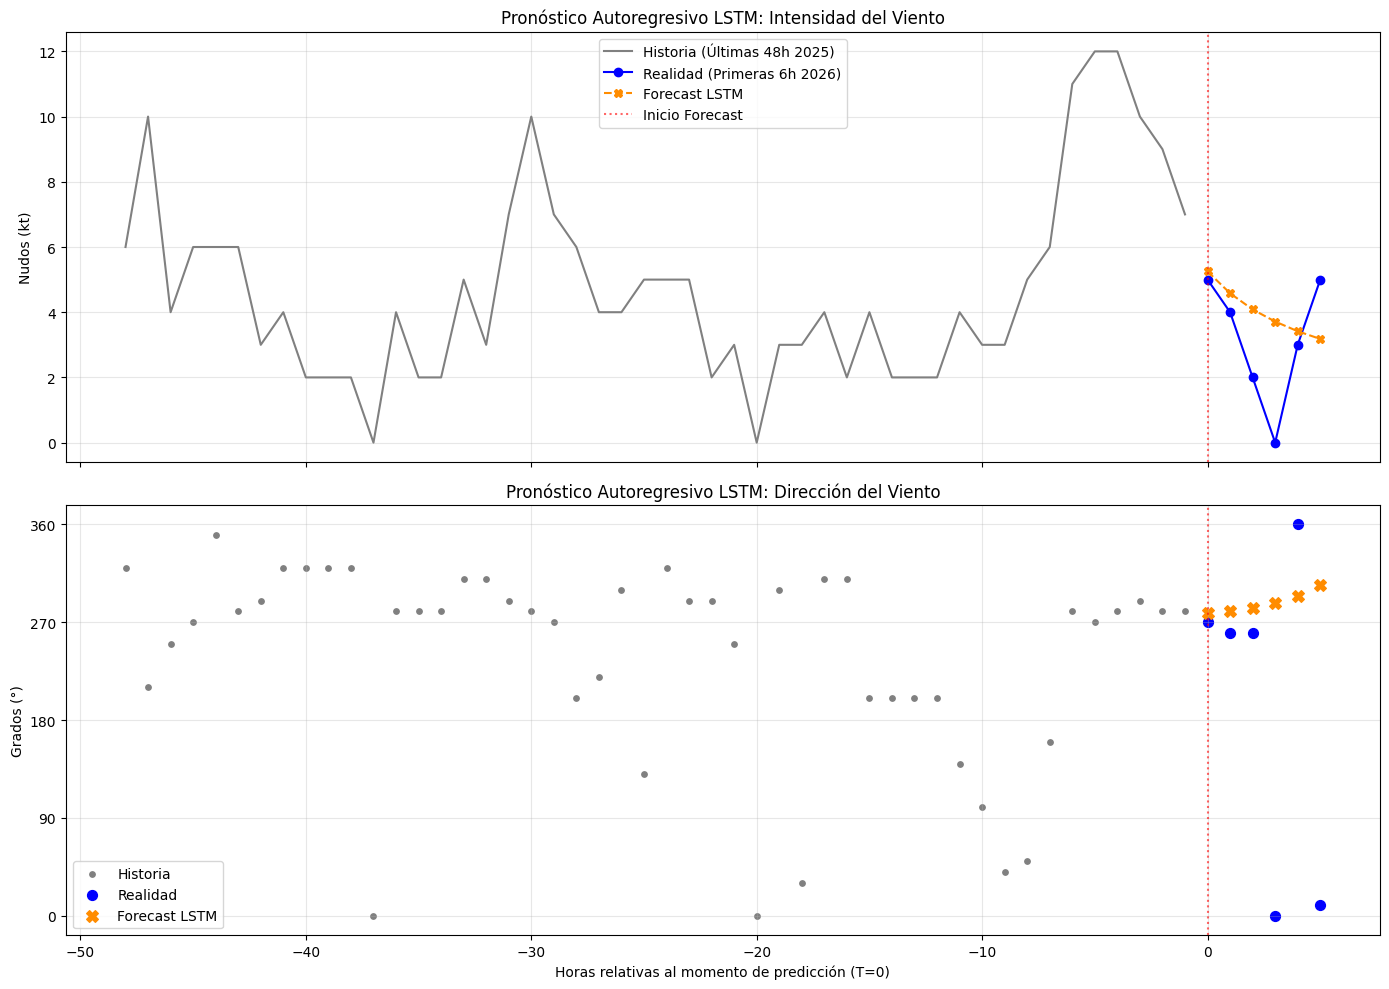

--- REPORTE DE PRONÓSTICO (T+1 a T+6) ---
Hora +1 | Real: 5.0kt @ 270° | Predicción LSTM: 5.3kt @ 278°
Hora +2 | Real: 4.0kt @ 260° | Predicción LSTM: 4.6kt @ 280°
Hora +3 | Real: 2.0kt @ 260° | Predicción LSTM: 4.1kt @ 283°
Hora +4 | Real: 0.0kt @ 0° | Predicción LSTM: 3.7kt @ 287°
Hora +5 | Real: 3.0kt @ 360° | Predicción LSTM: 3.4kt @ 294°
Hora +6 | Real: 5.0kt @ 10° | Predicción LSTM: 3.2kt @ 305°


In [174]:
# --- 1. Des-normalización de los datos ---
# forecast_escalado ya tiene forma (6, 3) -> dir_sin, dir_cos, intensidad_log

# Pronóstico
forecast_real = scaler_y.inverse_transform(forecast_escalado)  # (6, 3)

# Valores Reales del Test (primeras 6 horas de 2026)
real_real = scaler_y.inverse_transform(y_test[:horizonte_pred])  # (6, 3)

# Historia (últimas 48 horas de 2025 para contexto en la gráfica)
historia_real = scaler_y.inverse_transform(y_val[-n_back:])  # (48, 3)

# --- 2. Función de Transformación Física ---
def sincos_log_a_meteorologia(matriz):
    """Convierte array de [dir_sin, dir_cos, intensidad_log] a Intensidad y Dirección"""
    sin_vals = matriz[:, 0]
    cos_vals = matriz[:, 1]
    log_vals = matriz[:, 2]

    direccion  = np.degrees(np.arctan2(sin_vals, cos_vals)) % 360
    intensidad = np.expm1(log_vals)
    return intensidad, direccion

# Calculamos las variables operacionales
int_forecast, dir_forecast = sincos_log_a_meteorologia(forecast_real)
int_real,     dir_real     = sincos_log_a_meteorologia(real_real)
int_hist,     dir_hist     = sincos_log_a_meteorologia(historia_real)

# --- 3. Preparación de Ejes Temporales ---
tiempo_historia = np.arange(-n_back, 0)
tiempo_pred     = np.arange(0, horizonte_pred)

# --- 4. Visualización del Forecast ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Gráfico 1: Intensidad
ax1.plot(tiempo_historia, int_hist,     color='gray',       label='Historia (Últimas 48h 2025)')
ax1.plot(tiempo_pred,     int_real,     color='blue',       marker='o',               label='Realidad (Primeras 6h 2026)')
ax1.plot(tiempo_pred,     int_forecast, color='darkorange', marker='X', linestyle='--', label='Forecast LSTM')
ax1.axvline(x=0, color='red', linestyle=':', alpha=0.6, label='Inicio Forecast')
ax1.set_title('Pronóstico Autoregresivo LSTM: Intensidad del Viento')
ax1.set_ylabel('Nudos (kt)')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Gráfico 2: Dirección
ax2.scatter(tiempo_historia, dir_hist,     color='gray',       s=15,            label='Historia')
ax2.scatter(tiempo_pred,     dir_real,     color='blue',       marker='o', s=50, label='Realidad')
ax2.scatter(tiempo_pred,     dir_forecast, color='darkorange', marker='X', s=70, label='Forecast LSTM')
ax2.axvline(x=0, color='red', linestyle=':', alpha=0.6)
ax2.set_title('Pronóstico Autoregresivo LSTM: Dirección del Viento')
ax2.set_ylabel('Grados (°)')
ax2.set_yticks([0, 90, 180, 270, 360])
ax2.set_xlabel('Horas relativas al momento de predicción (T=0)')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

# --- 5. Tabla de resultados ---
print("--- REPORTE DE PRONÓSTICO (T+1 a T+6) ---")
for i in range(horizonte_pred):
    print(f"Hora +{i+1} | Real: {int_real[i]:.1f}kt @ {dir_real[i]:.0f}° | Predicción LSTM: {int_forecast[i]:.1f}kt @ {dir_forecast[i]:.0f}°")

Walk-forward con LSTM

In [175]:
def evaluar_modelo_lstm(modelo, data_X_escalada, data_y_escalada, scaler_y,
                        seq_length=48, horizon=6, dataset_name="Test", umbral_calma=2.0):
    print(f"Iniciando evaluación Walk-Forward para el set de {dataset_name}...")
    
    resultados_h = {h: {'int_real': [], 'int_pred': [], 'dir_real': [], 'dir_pred': []} 
                    for h in range(1, horizon + 1)}
    
    for t in range(seq_length, len(data_X_escalada) - horizon, horizon):
        
        ventana_actual_3d = np.expand_dims(data_X_escalada[t - seq_length : t], axis=0)
        
        forecast_escalado = predict_autoregressive(
            modelo,
            ventana_actual_3d,
            data_X_escalada[t : t + horizon, 3:],
            horizon
        )
        
        forecast_real = scaler_y.inverse_transform(forecast_escalado)
        real_real     = scaler_y.inverse_transform(data_y_escalada[t : t + horizon])
        
        for h_idx in range(horizon):
            paso = h_idx + 1
            
            sin_r, cos_r, log_r = real_real[h_idx]
            dir_r = np.degrees(np.arctan2(sin_r, cos_r)) % 360
            int_r = np.expm1(log_r)
            
            sin_p, cos_p, log_p = forecast_real[h_idx]
            dir_p = np.degrees(np.arctan2(sin_p, cos_p)) % 360
            int_p = np.expm1(log_p)
            
            # Intensidad: siempre se guarda
            resultados_h[paso]['int_real'].append(int_r)
            resultados_h[paso]['int_pred'].append(int_p)
            
            # Dirección: SOLO cuando el viento real supera el umbral de calma 
            if int_r > umbral_calma:
                resultados_h[paso]['dir_real'].append(dir_r)
                resultados_h[paso]['dir_pred'].append(dir_p)

    reporte = pd.DataFrame(index=[f"Hora {h}" for h in range(1, horizon + 1)], 
                           columns=['MAE_Intensidad (kt)', 'MAE_Direccion (grados)'])
    
    for h in range(1, horizon + 1):
        i_r = np.array(resultados_h[h]['int_real'])
        i_p = np.array(resultados_h[h]['int_pred'])
        d_r = np.array(resultados_h[h]['dir_real'])
        d_p = np.array(resultados_h[h]['dir_pred'])
        
        mae_int = mean_absolute_error(i_r, i_p)
        diff    = np.abs(d_r - d_p)
        mae_dir = np.mean(np.minimum(diff, 360 - diff))
        
        reporte.loc[f"Hora {h}"] = [mae_int, mae_dir]
        
    print(f"\n--- REPORTE LSTM: {dataset_name.upper()} ---")
    print(reporte.astype(float).round(2))
    return reporte


# --- Ejecución — CAMBIO: ahora recibe data_y y scaler_y por separado ---
reporte_val_lstm = evaluar_modelo_lstm(
    model, Xval_data, y_val, scaler_y,
    seq_length=n_back, horizon=horizonte_pred, dataset_name="Validación (2025)"
)

reporte_test_lstm = evaluar_modelo_lstm(
    model, Xtest_data, y_test, scaler_y,
    seq_length=n_back, horizon=horizonte_pred, dataset_name="Test (2026)"
)

Iniciando evaluación Walk-Forward para el set de Validación (2025)...

--- REPORTE LSTM: VALIDACIÓN (2025) ---
        MAE_Intensidad (kt)  MAE_Direccion (grados)
Hora 1                 1.88                   36.84
Hora 2                 2.08                   43.45
Hora 3                 2.17                   49.21
Hora 4                 2.25                   53.45
Hora 5                 2.26                   56.19
Hora 6                 2.38                   58.61
Iniciando evaluación Walk-Forward para el set de Test (2026)...

--- REPORTE LSTM: TEST (2026) ---
        MAE_Intensidad (kt)  MAE_Direccion (grados)
Hora 1                 1.64                   39.02
Hora 2                 1.88                   46.51
Hora 3                 2.01                   51.69
Hora 4                 2.04                   54.74
Hora 5                 1.97                   58.76
Hora 6                 1.92                   58.90


In [137]:
# GUARDAR MODELO
model.save('mejor_modelo_lstm_peso4.keras')
joblib.dump(scaler_X, 'scaler_X_peso4.pkl')
joblib.dump(scaler_y, 'scaler_y_peso4.pkl')
np.save('Xval_peso4.npy',  Xval_data)
np.save('Xtest_peso4.npy', Xtest_data)
np.save('y_val_peso4.npy',  y_val)
np.save('y_test_peso4.npy', y_test)


## GRU

c:\Users\Usuario\Documents\MAESTRÍA\Semestre 2\Deep learning\condapython3_9\.conda\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_8 (GRU)                     │ (None, 48, 200)        │       124,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 48, 200)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_9 (GRU)                     │ (None, 48, 100)        │        90,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 48, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_10 (GRU)                    │ (None, 50)             │        22,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 3)              │           153 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 237,753 (928.72 KB)

 Trainable params: 237,753 (928.72 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
411/411 ━━━━━━━━━━━━━━━━━━━━ 0s 522ms/step - loss: 5.4207
Epoch 1: val_loss improved from inf to 4.01382, saving model to mejor_modelo_gru.keras
411/411 ━━━━━━━━━━━━━━━━━━━━ 227s 539ms/step - loss: 5.4189 - val_loss: 4.0138
Epoch 2/50
411/411 ━━━━━━━━━━━━━━━━━━━━ 0s 550ms/step - loss: 4.1989
Epoch 2: val_loss improved from 4.01382 to 3.83476, saving model to mejor_modelo_gru.keras
411/411 ━━━━━━━━━━━━━━━━━━━━ 233s 567ms/step - loss: 4.1989 - val_loss: 3.8348
Epoch 3/50
411/411 ━━━━━━━━━━━━━━━━━━━━ 0s 527ms/step - loss: 4.1894
Epoch 3: val_loss improved from 3.83476 to 3.79170, saving model to mejor_modelo_gru.keras
411/411 ━━━━━━━━━━━━━━━━━━━━ 224s 544ms/step - loss: 4.1892 - val_loss: 3.7917
Epoch 4/50
411/411 ━━━━━━━━━━━━━━━━━━━━ 0s 522ms/step - loss: 4.0832
Epoch 4: val_loss did not improve from 3.79170
411/411 ━━━━━━━━━━━━━━━━━━━━ 221s 538ms/step - loss: 4.0832 - val_loss: 3.7989
Epoch 5/50
411/411 ━━━━━━━━━━━━━━━━━━━━ 0s 525ms/step - loss: 4.0287
Epoch 5: val_loss impro

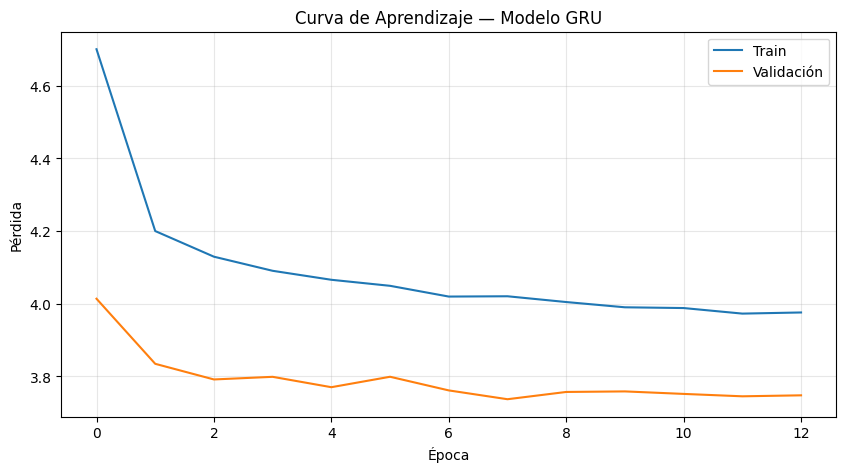

Iniciando evaluación Walk-Forward para el set de GRU - Validación (2025)...

--- REPORTE LSTM: GRU - VALIDACIÓN (2025) ---
        MAE_Intensidad (kt)  MAE_Direccion (grados)
Hora 1                 1.35                   30.50
Hora 2                 1.45                   36.08
Hora 3                 1.47                   40.15
Hora 4                 1.53                   42.92
Hora 5                 1.53                   44.82
Hora 6                 1.55                   45.12
Iniciando evaluación Walk-Forward para el set de GRU - Test (2026)...

--- REPORTE LSTM: GRU - TEST (2026) ---
        MAE_Intensidad (kt)  MAE_Direccion (grados)
Hora 1                 1.34                   28.46
Hora 2                 1.37                   37.16
Hora 3                 1.39                   38.87
Hora 4                 1.27                   43.21
Hora 5                 1.32                   44.00
Hora 6                 1.40                   46.56


In [182]:
# ========== MODELO GRU ==========


SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

model_gru = Sequential([
    GRU(200, activation='relu', return_sequences=True, input_shape=(n_back, n_features)),
    Dropout(0.2),
    GRU(100, activation='relu', return_sequences=True),
    Dropout(0.2),
    GRU(50, activation='relu'),
    Dropout(0.2),
    Dense(n_outputs)
])

model_gru.compile(optimizer=Adam(learning_rate=1e-3), loss=perdida_circular)
model_gru.summary()

# Callbacks
checkpoint = ModelCheckpoint(
    filepath='mejor_modelo_gru.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Entrenamiento
history_gru = model_gru.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=[checkpoint, early_stop],
    verbose=1
)

# Cargar mejor checkpoint
model_gru = load_model('mejor_modelo_gru.keras',
                       custom_objects={'perdida_circular': perdida_circular})

# Curva de aprendizaje
plt.figure(figsize=(10, 5))
plt.plot(history_gru.history['loss'],     label='Train')
plt.plot(history_gru.history['val_loss'], label='Validación')
plt.title('Curva de Aprendizaje — Modelo GRU')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Evaluación
reporte_val_gru = evaluar_modelo_lstm(
    model_gru, Xval_data, y_val, scaler_y,
    seq_length=n_back, horizon=horizonte_pred, dataset_name="GRU - Validación (2025)"
)

reporte_test_gru = evaluar_modelo_lstm(
    model_gru, Xtest_data, y_test, scaler_y,
    seq_length=n_back, horizon=horizonte_pred, dataset_name="GRU - Test (2026)"
)

In [105]:
#guardar modelo y escaladores para uso futuro
import joblib
model_gru.save('mejor_modelo_gru.keras')
joblib.dump(scaler_X, 'scaler_X.pkl')
joblib.dump(scaler_y, 'scaler_y.pkl')
np.save('Xval_data.npy', Xval_data)
np.save('Xtest_data.npy', Xtest_data)
np.save('y_val.npy', y_val)
np.save('y_test.npy', y_test)

## CNN + GRU

c:\Users\Usuario\Documents\MAESTRÍA\Semestre 2\Deep learning\condapython3_9\.conda\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 46, 64)         │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 23, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 100)            │        49,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3)              │           303 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,127 (199.71 KB)

 Trainable params: 51,127 (199.71 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
411/411 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 3.0557
Epoch 1: val_loss improved from inf to 2.20136, saving model to mejor_modelo_cnn_gru.keras
411/411 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - loss: 3.0547 - val_loss: 2.2014
Epoch 2/25
410/411 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 2.2911
Epoch 2: val_loss improved from 2.20136 to 2.13687, saving model to mejor_modelo_cnn_gru.keras
411/411 ━━━━━━━━━━━━━━━━━━━━ 17s 41ms/step - loss: 2.2912 - val_loss: 2.1369
Epoch 3/25
411/411 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 2.2364
Epoch 3: val_loss improved from 2.13687 to 2.11633, saving model to mejor_modelo_cnn_gru.keras
411/411 ━━━━━━━━━━━━━━━━━━━━ 17s 40ms/step - loss: 2.2364 - val_loss: 2.1163
Epoch 4/25
410/411 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 2.2112
Epoch 4: val_loss improved from 2.11633 to 2.09782, saving model to mejor_modelo_cnn_gru.keras
411/411 ━━━━━━━━━━━━━━━━━━━━ 17s 40ms/step - loss: 2.2112 - val_loss: 2.0978
Epoch 5/25
410/411 ━━━━━━━━━━━━━━━━━━━━ 0s 4

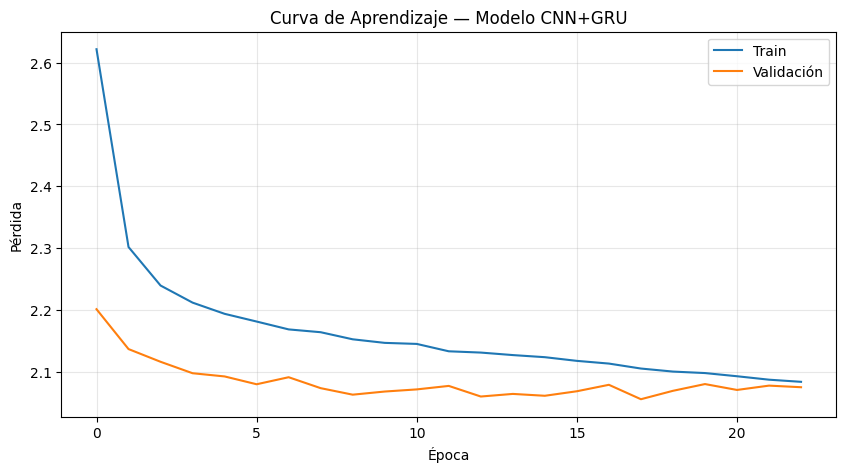

Iniciando evaluación Walk-Forward para el set de CNN+GRU - Validación (2025)...

--- REPORTE LSTM: CNN+GRU - VALIDACIÓN (2025) ---
        MAE_Intensidad (kt)  MAE_Direccion (grados)
Hora 1                 1.33                   30.73
Hora 2                 1.40                   36.04
Hora 3                 1.42                   40.60
Hora 4                 1.56                   43.25
Hora 5                 1.54                   44.01
Hora 6                 1.52                   44.27
Iniciando evaluación Walk-Forward para el set de CNN+GRU - Test (2026)...

--- REPORTE LSTM: CNN+GRU - TEST (2026) ---
        MAE_Intensidad (kt)  MAE_Direccion (grados)
Hora 1                 1.31                   28.74
Hora 2                 1.31                   36.28
Hora 3                 1.38                   38.12
Hora 4                 1.29                   41.20
Hora 5                 1.28                   42.13
Hora 6                 1.37                   45.30


In [107]:
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

model_cnn_gru = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(n_back, n_features)),
    MaxPooling1D(pool_size=2),
    GRU(100, activation='relu'),
    Dense(n_outputs)
])

model_cnn_gru.compile(optimizer=Adam(learning_rate=1e-3), loss=perdida_circular)
model_cnn_gru.summary()

# Callbacks
checkpoint = ModelCheckpoint(
    filepath='mejor_modelo_cnn_gru.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Entrenamiento
history_cnn_gru = model_cnn_gru.fit(
    train_generator,
    validation_data=val_generator,
    epochs=25,
    callbacks=[checkpoint, early_stop],
    verbose=1
)

# Cargar mejor checkpoint
model_cnn_gru = load_model('mejor_modelo_cnn_gru.keras',
                           custom_objects={'perdida_circular': perdida_circular})

# Curva de aprendizaje
plt.figure(figsize=(10, 5))
plt.plot(history_cnn_gru.history['loss'],     label='Train')
plt.plot(history_cnn_gru.history['val_loss'], label='Validación')
plt.title('Curva de Aprendizaje — Modelo CNN+GRU')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Evaluación
reporte_val_cnn_gru = evaluar_modelo_lstm(
    model_cnn_gru, Xval_data, y_val, scaler_y,
    seq_length=n_back, horizon=horizonte_pred, dataset_name="CNN+GRU - Validación (2025)"
)

reporte_test_cnn_gru = evaluar_modelo_lstm(
    model_cnn_gru, Xtest_data, y_test, scaler_y,
    seq_length=n_back, horizon=horizonte_pred, dataset_name="CNN+GRU - Test (2026)"
)

## Pruebas con u y v

In [ ]:
# Filtrar desde 2013
df_uv= df_pre_copy.loc['2013-01-01':, ['viento', 'temperatura', 'rocio', 'direccion', 'intensidad_kt', 'rafaga_kt', 'dir_sin', 'dir_cos', 'intensidad_log', 'u', 'v']].copy()

In [123]:
df_uv.head()

,viento,temperatura,rocio,direccion,intensidad_kt,rafaga_kt,dir_sin,dir_cos,intensidad_log,u,v
FECHA_REPORTE,,,,,,,,,,,
2013-01-01 00:00:00,01003KT,14.0,6.0,10.0,3.0,0.0,0.173648,0.984808,1.386294,-0.520945,-2.954423
2013-01-01 01:00:00,03005KT,13.0,7.0,30.0,5.0,0.0,0.500000,0.866025,1.791759,-2.500000,-4.330127
2013-01-01 02:00:00,07003KT,13.0,7.0,70.0,3.0,0.0,0.939693,0.342020,1.386294,-2.819078,-1.026060
2013-01-01 03:00:00,03003KT,10.0,7.0,30.0,3.0,0.0,0.500000,0.866025,1.386294,-1.500000,-2.598076
2013-01-01 04:00:00,03004KT,9.0,7.0,30.0,4.0,0.0,0.500000,0.866025,1.609438,-2.000000,-3.464102


In [124]:
## RESAMPLE E INTERPOLACIÓN
# =========================================================
reglas = {
    'u':             'mean',
    'v':             'mean',

}

df_uv = df_uv.resample('1h').agg(reglas)

df_uv['u']             = df_uv['u'].interpolate(method='linear')
df_uv['v']             = df_uv['v'].interpolate(method='linear')


# =========================================================
# FASE 3: FEATURES TEMPORALES
# =========================================================
df_uv['hora_sin'] = np.sin(2 * np.pi * df_uv.index.hour / 24)
df_uv['hora_cos'] = np.cos(2 * np.pi * df_uv.index.hour / 24)

# =========================================================
# FASE 4: EXPORTAR
# =========================================================


print(f"Shape: {df_uv.shape}")
print(f"Columnas: {df_uv.columns.tolist()}")
print(f"Rango: {df_uv.index.min()} → {df_uv.index.max()}")
print(df_uv.head())

df_uv.to_csv('DATOS_ENTRENAMIENTO_UV.csv')

Shape: (116323, 4)
Columnas: ['u', 'v', 'hora_sin', 'hora_cos']
Rango: 2013-01-01 00:00:00 → 2026-04-09 18:00:00
                            u         v  hora_sin  hora_cos
FECHA_REPORTE                                              
2013-01-01 00:00:00 -0.520945 -2.954423  0.000000  1.000000
2013-01-01 01:00:00 -2.500000 -4.330127  0.258819  0.965926
2013-01-01 02:00:00 -2.819078 -1.026060  0.500000  0.866025
2013-01-01 03:00:00 -1.500000 -2.598076  0.707107  0.707107
2013-01-01 04:00:00 -2.000000 -3.464102  0.866025  0.500000


Train: 105192 | Val: 8760 | Test: 2371
Xtrain: (105192, 4) | y_train: (105192, 2)
X: (256, 48, 4) | y: (256, 2)


c:\Users\Usuario\Documents\MAESTRÍA\Semestre 2\Deep learning\condapython3_9\.conda\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 200)            │       164,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │           402 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 164,402 (642.20 KB)

 Trainable params: 164,402 (642.20 KB)

 Non-trainable params: 0 (0.00 B)

c:\Users\Usuario\Documents\MAESTRÍA\Semestre 2\Deep learning\condapython3_9\.conda\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
411/411 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - loss: 0.5811
Epoch 1: val_loss improved from inf to 0.35213, saving model to mejor_modelo_lstm_uv.keras
411/411 ━━━━━━━━━━━━━━━━━━━━ 68s 162ms/step - loss: 0.5809 - val_loss: 0.3521
Epoch 2/25
411/411 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - loss: 0.4282
Epoch 2: val_loss improved from 0.35213 to 0.34189, saving model to mejor_modelo_lstm_uv.keras
411/411 ━━━━━━━━━━━━━━━━━━━━ 63s 154ms/step - loss: 0.4282 - val_loss: 0.3419
Epoch 3/25
411/411 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - loss: 0.4223
Epoch 3: val_loss improved from 0.34189 to 0.33708, saving model to mejor_modelo_lstm_uv.keras
411/411 ━━━━━━━━━━━━━━━━━━━━ 70s 169ms/step - loss: 0.4223 - val_loss: 0.3371
Epoch 4/25
411/411 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - loss: 0.4187
Epoch 4: val_loss improved from 0.33708 to 0.33567, saving model to mejor_modelo_lstm_uv.keras
411/411 ━━━━━━━━━━━━━━━━━━━━ 64s 156ms/step - loss: 0.4187 - val_loss: 0.3357
Epoch 5/25
411/411 ━━━━━━━━━━━━━━━━━

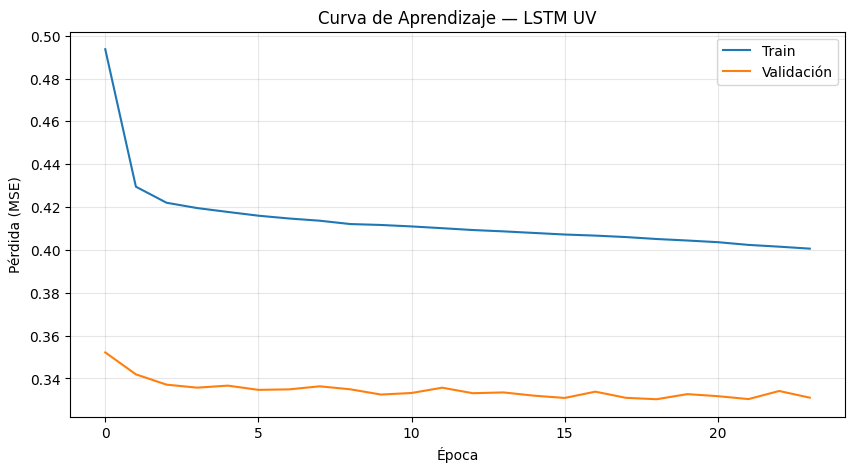


--- REPORTE DE PRONÓSTICO (T+1 a T+6) ---
Hora +1 | Real: 10.0kt @ 40° | Predicción: 2.1kt @ 53°
Hora +2 | Real: 7.0kt @ 30° | Predicción: 2.1kt @ 59°
Hora +3 | Real: 7.0kt @ 50° | Predicción: 2.3kt @ 50°
Hora +4 | Real: 6.0kt @ 60° | Predicción: 2.6kt @ 44°
Hora +5 | Real: 4.0kt @ 40° | Predicción: 2.8kt @ 40°
Hora +6 | Real: 2.0kt @ 40° | Predicción: 2.9kt @ 37°
Iniciando evaluación Walk-Forward para el set de LSTM UV - Validación (2025)...

--- REPORTE: LSTM UV - VALIDACIÓN (2025) ---
        MAE_Intensidad (kt)  MAE_Direccion (grados)
Hora 1                 1.63                   32.15
Hora 2                 1.78                   36.61
Hora 3                 1.88                   42.07
Hora 4                 2.06                   44.01
Hora 5                 2.13                   45.30
Hora 6                 2.18                   45.61
Iniciando evaluación Walk-Forward para el set de LSTM UV - Test (2026)...

--- REPORTE: LSTM UV - TEST (2026) ---
        MAE_Intensidad (kt) 

In [125]:
# =========================================================
# 0. SEMILLA
# =========================================================
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# =========================================================
# 1. PARTIR PRIMERO
# =========================================================
features_modelo = ['u', 'v', 'hora_sin', 'hora_cos']  # 4 features
targets         = ['u', 'v']                            # predecimos u y v
n_features      = 4
n_outputs       = 2
n_back          = 48
horizonte_pred  = 6
batch_size      = 256

train_df = df_uv.loc[:'2024-12-31']
val_df   = df_uv.loc['2025-01-01':'2025-12-31']
test_df  = df_uv.loc['2026-01-01':]

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

# =========================================================
# 2. ESCALAR SOLO CON TRAIN
# =========================================================
scaler_X = StandardScaler()
scaler_y = StandardScaler()

Xtrain_data = scaler_X.fit_transform(train_df[features_modelo].to_numpy())
Xval_data   = scaler_X.transform(val_df[features_modelo].to_numpy())
Xtest_data  = scaler_X.transform(test_df[features_modelo].to_numpy())

y_train = scaler_y.fit_transform(train_df[targets].to_numpy())
y_val   = scaler_y.transform(val_df[targets].to_numpy())
y_test  = scaler_y.transform(test_df[targets].to_numpy())

print(f"Xtrain: {Xtrain_data.shape} | y_train: {y_train.shape}")

# =========================================================
# 3. GENERADORES
# =========================================================
train_generator = TimeseriesGenerator(Xtrain_data, y_train, length=n_back, batch_size=batch_size)
val_generator   = TimeseriesGenerator(Xval_data,   y_val,   length=n_back, batch_size=batch_size)

x_batch, y_batch = train_generator[0]
print(f"X: {x_batch.shape} | y: {y_batch.shape}")

# =========================================================
# 4. MODELO LSTM
# =========================================================
model_lstm_uv = Sequential([
    LSTM(200, activation='relu', input_shape=(n_back, n_features)),
    Dense(n_outputs)
])

model_lstm_uv.compile(optimizer=Adam(learning_rate=1e-3), loss='mse')
model_lstm_uv.summary()

# =========================================================
# 5. CALLBACKS
# =========================================================
checkpoint = ModelCheckpoint(
    filepath='mejor_modelo_lstm_uv.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# =========================================================
# 6. ENTRENAMIENTO
# =========================================================
history_lstm_uv = model_lstm_uv.fit(
    train_generator,
    validation_data=val_generator,
    epochs=25,
    callbacks=[checkpoint, early_stop],
    verbose=1
)

model_lstm_uv = load_model('mejor_modelo_lstm_uv.keras')

# =========================================================
# 7. CURVA DE APRENDIZAJE
# =========================================================
plt.figure(figsize=(10, 5))
plt.plot(history_lstm_uv.history['loss'],     label='Train')
plt.plot(history_lstm_uv.history['val_loss'], label='Validación')
plt.title('Curva de Aprendizaje — LSTM UV')
plt.xlabel('Época')
plt.ylabel('Pérdida (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# =========================================================
# 8. FUNCIONES
# =========================================================
def predict_autoregressive_uv(modelo, initial_window, exog_future, horizon):
    """
    initial_window: (1, 48, 4) -> u, v, hora_sin, hora_cos
    exog_future:    (horizon, 2) -> hora_sin, hora_cos (conocidas en el futuro)
    """
    current_window = np.copy(initial_window)
    predictions    = []

    for i in range(horizon):
        # 1. Predecir u, v
        next_uv = modelo.predict(current_window, verbose=0)  # (1, 2)
        predictions.append(next_uv[0])

        # 2. Construir nuevo timestep: u, v predichos + hora_sin, hora_cos futuros
        next_step    = np.concatenate([next_uv[0], exog_future[i]])  # (4,)
        next_step_3d = next_step.reshape(1, 1, n_features)

        # 3. Actualizar ventana
        current_window = np.concatenate(
            [current_window[:, 1:, :], next_step_3d], axis=1
        )

    return np.array(predictions)  # (horizon, 2)


def uv_a_meteorologia(matriz_uv):
    """Convierte [u, v] a intensidad (kt) y dirección (°)"""
    u = matriz_uv[:, 0]
    v = matriz_uv[:, 1]
    intensidad = np.sqrt(u**2 + v**2)
    direccion  = (np.degrees(np.arctan2(-u, -v)) % 360)
    return intensidad, direccion


def evaluar_modelo_uv(modelo, data_X_escalada, data_y_escalada, scaler_y,
                      seq_length=48, horizon=6, dataset_name="Test", umbral_calma=2.0):
    print(f"Iniciando evaluación Walk-Forward para el set de {dataset_name}...")

    resultados_h = {h: {'int_real': [], 'int_pred': [], 'dir_real': [], 'dir_pred': []}
                    for h in range(1, horizon + 1)}

    for t in range(seq_length, len(data_X_escalada) - horizon, horizon):

        ventana_3d = np.expand_dims(data_X_escalada[t - seq_length : t], axis=0)

        # Exógenas futuras: hora_sin, hora_cos (columnas 2 y 3)
        exog_future = data_X_escalada[t : t + horizon, 2:]  # (horizon, 2)

        forecast_escalado = predict_autoregressive_uv(modelo, ventana_3d, exog_future, horizon)

        forecast_nudos = scaler_y.inverse_transform(forecast_escalado)
        real_nudos     = scaler_y.inverse_transform(data_y_escalada[t : t + horizon])

        for h_idx in range(horizon):
            paso = h_idx + 1
            int_r, dir_r = uv_a_meteorologia(real_nudos[h_idx:h_idx+1])
            int_p, dir_p = uv_a_meteorologia(forecast_nudos[h_idx:h_idx+1])

            resultados_h[paso]['int_real'].append(int_r[0])
            resultados_h[paso]['int_pred'].append(int_p[0])

            if int_r[0] >= umbral_calma:
                resultados_h[paso]['dir_real'].append(dir_r[0])
                resultados_h[paso]['dir_pred'].append(dir_p[0])

    reporte = pd.DataFrame(index=[f"Hora {h}" for h in range(1, horizon + 1)],
                           columns=['MAE_Intensidad (kt)', 'MAE_Direccion (grados)'])

    for h in range(1, horizon + 1):
        i_r = np.array(resultados_h[h]['int_real'])
        i_p = np.array(resultados_h[h]['int_pred'])
        d_r = np.array(resultados_h[h]['dir_real'])
        d_p = np.array(resultados_h[h]['dir_pred'])

        mae_int = mean_absolute_error(i_r, i_p)
        diff    = np.abs(d_r - d_p)
        mae_dir = np.mean(np.minimum(diff, 360 - diff))

        reporte.loc[f"Hora {h}"] = [mae_int, mae_dir]

    print(f"\n--- REPORTE: {dataset_name.upper()} ---")
    print(reporte.astype(float).round(2))
    return reporte

# =========================================================
# 9. PRUEBA DE CONCEPTO 6H
# =========================================================
ultima_ventana_val    = Xval_data[-n_back:]
ultima_ventana_val_3d = np.expand_dims(ultima_ventana_val, axis=0)

# Exógenas futuras: hora_sin, hora_cos (columnas 2 y 3)
exog_future = Xtest_data[:horizonte_pred, 2:]  # (6, 2)

forecast_escalado = predict_autoregressive_uv(
    model_lstm_uv, ultima_ventana_val_3d, exog_future, horizonte_pred
)

forecast_nudos = scaler_y.inverse_transform(forecast_escalado)
real_nudos     = scaler_y.inverse_transform(y_test[:horizonte_pred])

int_forecast, dir_forecast = uv_a_meteorologia(forecast_nudos)
int_real,     dir_real     = uv_a_meteorologia(real_nudos)

print("\n--- REPORTE DE PRONÓSTICO (T+1 a T+6) ---")
for i in range(horizonte_pred):
    print(f"Hora +{i+1} | Real: {int_real[i]:.1f}kt @ {dir_real[i]:.0f}° | Predicción: {int_forecast[i]:.1f}kt @ {dir_forecast[i]:.0f}°")

# =========================================================
# 10. EVALUACIÓN WALK-FORWARD
# =========================================================
reporte_val_lstm_uv = evaluar_modelo_uv(
    model_lstm_uv, Xval_data, y_val, scaler_y,
    seq_length=n_back, horizon=horizonte_pred,
    dataset_name="LSTM UV - Validación (2025)"
)

reporte_test_lstm_uv = evaluar_modelo_uv(
    model_lstm_uv, Xtest_data, y_test, scaler_y,
    seq_length=n_back, horizon=horizonte_pred,
    dataset_name="LSTM UV - Test (2026)"
)
